# Single Output

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd
try:
    df = pd.read_csv('/content/drive/MyDrive/data.csv')
except Exception as e:
    print(f"An error occurred while loading the DataFrame: {e}")
    df = pd.DataFrame()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías a utilizar
import tensorflow as tf
from keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Hiperparámetros
train_percentage = 0.75 # % de datos a apartar para el entrenamiento
n = 2 # Número de capas ocultas del modelo
units = 16 # Número de neuronas por capa
activation = "relu" # Función de activación
learning_rate = 0.001 # Taza de aprendizaje
loss = "mae" # Función de pérdida
batch_size = 40 # Tamaño de lote
epochs = 150 # Número de iteraciones de entrenamiento

In [ ]:
df = df.iloc[:1273] # Se toman los primeros 1274 datos para el dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True) #Randomiza los datos


# Se necesita poner la columna de CondensedBinary2DGeometry en un array para poder entrenar el modelo:
df['CondensedBinary2DGeometry'] = df['CondensedBinary2DGeometry'].apply(
    lambda val: val if isinstance(val, np.ndarray) else np.array(list(str(int(val)).zfill(15)), dtype=int)
)

In [ ]:
# División en entrenamiento y validación
trainset = df.sample(frac=train_percentage, random_state=42) # Se extraen datos para el entrenamiento
x_train = np.stack(trainset['CondensedBinary2DGeometry'].values)
testset = df.drop(trainset.index) # Y se le quitan esos mismos al dataset para crear los datos de prueba
x_test = np.stack(testset['CondensedBinary2DGeometry'].values) # Si se usara la columna directamente del csv, el modelo entrenaria con una magnitud.

In [ ]:
# Normalizacion
# Se deben de hacer normalizaciones por aparte, ya que se no se puede normalizar la columna de CondensedBinary2DGeometry,
# por lo que hacemos un drop. Por esta misma razon, se define el trainset primero, ya que si se hiciera despues, este no incluiria a
# la columna de entrada.

# TRAINSET
s_norm_train = trainset.copy()
s_norm_train = s_norm_train.drop(columns=['CondensedBinary2DGeometry'])

max_val_train = s_norm_train.max(axis=0)  # Se obtiene el máximo de cada columna
min_val_train = s_norm_train.min(axis=0)  # Se obtiene el mínimo de cada columna
difference = max_val_train - min_val_train  # Se obtiene la diferencia de los dos
new_trainset = (s_norm_train - min_val_train)/(difference)  # Y se utiliza para normalizarlas
new_trainset = new_trainset.astype(float)  # Se asegura que los datos sean tipo float

# TESTSET
s_norm_test = testset.copy()
s_norm_test = s_norm_test.drop(columns=['CondensedBinary2DGeometry'])

max_val_test = s_norm_test.max(axis=0)  # Se obtiene el máximo de cada columna
min_val_test = s_norm_test.min(axis=0)  # Se obtiene el mínimo de cada columna
new_testset = (s_norm_test - min_val_train)/(difference)  # Se usa min_val_train y difference porque son los parámetros de la transformación.
new_testset = new_testset.astype(float)  # Se asegura que los datos sean tipo float

In [ ]:
# Modificá la función para que también devuelva el modelo
def entrenar_modelo(n, units, learning_rate, train_set, test_set, n_output):

    network = models.Sequential()
    network.add(Input(shape=(15,)))

    for i in range(n - 1):
        network.add(layers.Dense(units=units, activation="relu"))

    network.add(layers.Dense(units=n_output, activation="linear"))

    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss
    )

    history = network.fit(
        x_train,
        train_set,
        validation_data=(x_test, test_set),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )

    return history, network

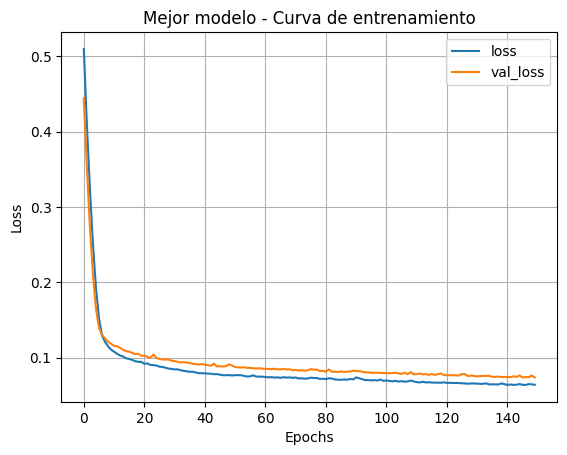

In [ ]:
history_mejor, modelo_location = entrenar_modelo(
    n=2,
    units=16,
    learning_rate=0.001,
    train_set=new_trainset['BandGapLocation'],
    test_set=new_testset['BandGapLocation'],
    n_output=1
)

# Ver la curva de entrenamiento
plt.figure()
plt.plot(history_mejor.history['loss'], label='loss')
plt.plot(history_mejor.history['val_loss'], label='val_loss')
plt.title("Mejor modelo - Curva de entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

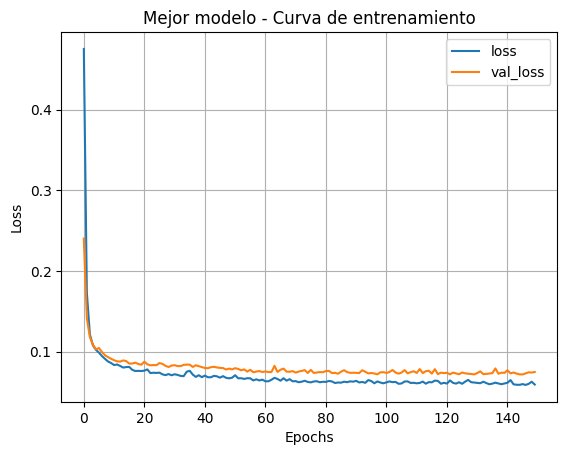

In [ ]:
history_mejor, mejor_modelo_location = entrenar_modelo(
    n=2,
    units=16,
    learning_rate=0.005,
    train_set=new_trainset['BandGapLocation'],
    test_set=new_testset['BandGapLocation'],
    n_output=1
)

# Ver la curva de entrenamiento
plt.figure()
plt.plot(history_mejor.history['loss'], label='loss')
plt.plot(history_mejor.history['val_loss'], label='val_loss')
plt.title("Mejor modelo - Curva de entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

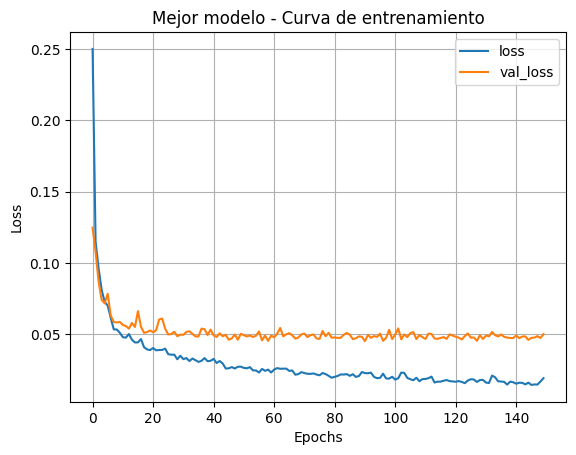

In [ ]:
history_mejor, mejor_modelo_width = entrenar_modelo(
    n=3,        # probá con 3 capas
    units=256,   # y más neuronas
    learning_rate=0.0075,
    train_set=new_trainset['BandGapWidth'],
    test_set=new_testset['BandGapWidth'],
    n_output=1
)

# Ver la curva de entrenamiento
plt.figure()
plt.plot(history_mejor.history['loss'], label='loss')
plt.plot(history_mejor.history['val_loss'], label='val_loss')
plt.title("Mejor modelo - Curva de entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

No vale la pena aumentar u, ya que ambos tienen un loss final similar. el  learning rate de 0.0005 hace que la curva dure mas en converger y no vale la pena. Mejores hiperparametros: 2 capas ocultas, 16 neuronas, tasa de aprendizaje de 0.001.

In [ ]:
np.random.seed(42)
indices_val = np.random.choice(len(x_test), size=10, replace=False)

print("=== VALIDACIÓN BandGapLocation ===")
for idx in indices_val:
    dato = x_test[idx]
    real_norm = new_testset['BandGapLocation'].iloc[idx]
    pred_norm = mejor_modelo_location.predict(dato.reshape(1, -1), verbose=0)[0][0]
    loc_real = real_norm * difference['BandGapLocation'] + min_val_train['BandGapLocation']
    loc_pred = pred_norm * difference['BandGapLocation'] + min_val_train['BandGapLocation']
    print(f"\nDato ingresado: {dato}")
    print(f"  BandGapLocation  - Real: {loc_real:.2f}  |  Estimado: {loc_pred:.2f}")

print("\n=== VALIDACIÓN BandGapWidth ===")
for idx in indices_val:
    dato = x_test[idx]
    real_norm = new_testset['BandGapWidth'].iloc[idx]
    pred_norm = mejor_modelo_width.predict(dato.reshape(1, -1), verbose=0)[0][0]
    width_real = real_norm * difference['BandGapWidth'] + min_val_train['BandGapWidth']
    width_pred = pred_norm * difference['BandGapWidth'] + min_val_train['BandGapWidth']
    print(f"\nDato ingresado: {dato}")
    print(f"  BandGapWidth  - Real: {width_real:.2f}  |  Estimado: {width_pred:.2f}")

    # Porcentaje de aciertos dentro de un margen de error
for modelo, col, color in [
    (mejor_modelo_location, 'BandGapLocation', 'steelblue'),
    (mejor_modelo_width, 'BandGapWidth', 'darkorange')
]:
    predicciones = modelo.predict(x_test, verbose=0)[:, 0]
    reales_norm = new_testset[col].values

    pred_desnorm = predicciones * difference[col] + min_val_train[col]
    real_desnorm = reales_norm * difference[col] + min_val_train[col]

    # Error porcentual absoluto por predicción
    error_porcentual = np.abs((real_desnorm - pred_desnorm) / real_desnorm) * 100

    for margen in [5, 10, 20]:
        aciertos = np.mean(error_porcentual <= margen) * 100
        print(f"{col} - Predicciones dentro del {margen}% de error: {aciertos:.1f}%")

    print(f"{col} - Error porcentual promedio: {np.mean(error_porcentual):.1f}%\n")

=== VALIDACIÓN BandGapLocation ===

Dato ingresado: [0 0 0 0 0 0 0 1 0 0 0 1 1 0 1]
  BandGapLocation  - Real: 642.54  |  Estimado: 700.40

Dato ingresado: [0 0 0 0 0 0 0 0 1 0 1 0 1 0 1]
  BandGapLocation  - Real: 713.53  |  Estimado: 590.52

Dato ingresado: [0 0 0 0 0 1 0 0 1 0 0 0 1 0 0]
  BandGapLocation  - Real: 656.48  |  Estimado: 393.53

Dato ingresado: [0 0 0 0 0 1 1 0 0 1 0 0 1 0 1]
  BandGapLocation  - Real: 721.73  |  Estimado: 779.99

Dato ingresado: [0 0 0 0 1 0 1 0 1 0 0 0 0 0 0]
  BandGapLocation  - Real: 936.95  |  Estimado: 947.55

Dato ingresado: [0 0 0 0 0 1 0 1 0 1 0 1 1 0 1]
  BandGapLocation  - Real: 823.60  |  Estimado: 770.54

Dato ingresado: [0 0 0 0 0 1 0 0 1 0 0 1 0 1 0]
  BandGapLocation  - Real: 835.19  |  Estimado: 681.15

Dato ingresado: [0 0 0 0 0 0 1 0 1 0 0 0 1 1 1]
  BandGapLocation  - Real: 698.60  |  Estimado: 772.91

Dato ingresado: [0 0 0 0 0 0 1 1 0 1 1 0 1 0 0]
  BandGapLocation  - Real: 1294.32  |  Estimado: 1289.66

Dato ingresado: [0 0 0 0 0


--- BandGapLocation ---
  MSE  : 31521.8285
  RMSE : 177.5439
  MAE  : 134.4352
  R²   : 0.8045

--- BandGapWidth ---
  MSE  : 6823.8512
  RMSE : 82.6066
  MAE  : 56.1139
  R²   : 0.8941


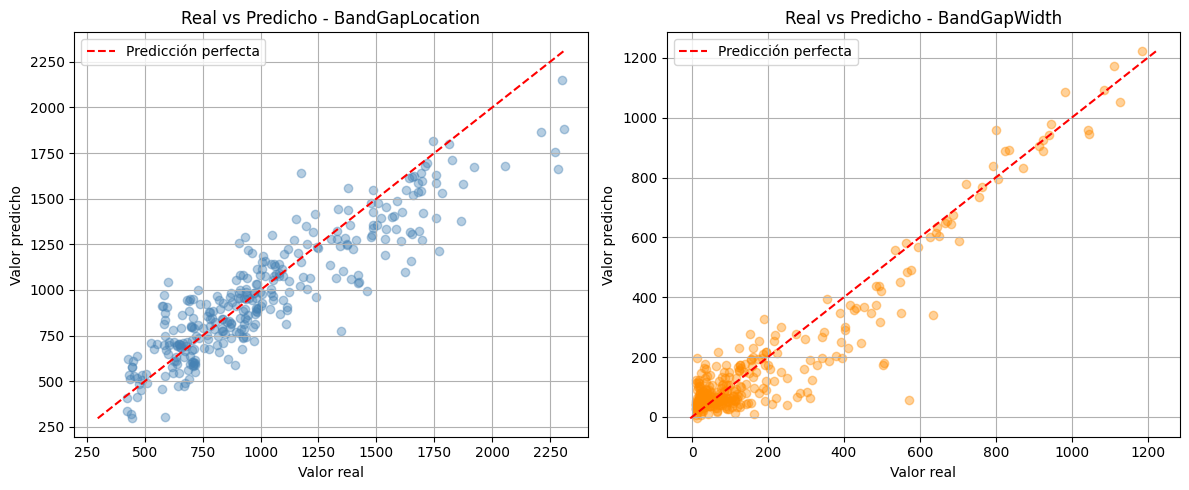

In [ ]:
# ============================================================
# VALIDACIÓN GRÁFICA: Real vs Predicho
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for modelo, col, color in [
    (mejor_modelo_location, 'BandGapLocation', 'steelblue'),
    (mejor_modelo_width, 'BandGapWidth', 'darkorange')
]:
    predicciones = modelo.predict(x_test, verbose=0).flatten()
    reales_norm = new_testset[col].values

    pred_desnorm = predicciones * difference[col] + min_val_train[col]
    real_desnorm = reales_norm * difference[col] + min_val_train[col]

    i = 0 if col == 'BandGapLocation' else 1
    axes[i].scatter(real_desnorm, pred_desnorm, alpha=0.4, color=color)
    min_val = min(real_desnorm.min(), pred_desnorm.min())
    max_val = max(real_desnorm.max(), pred_desnorm.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
    axes[i].set_xlabel("Valor real")
    axes[i].set_ylabel("Valor predicho")
    axes[i].set_title(f"Real vs Predicho - {col}")
    axes[i].legend()
    axes[i].grid()

    mse  = mean_squared_error(real_desnorm, pred_desnorm)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(real_desnorm, pred_desnorm)
    r2   = r2_score(real_desnorm, pred_desnorm)
    print(f"\n--- {col} ---")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PUNTO 3: Single Output - BandGapLocation
# ============================================================

_, modelo_location = entrenar_modelo(
    n=2,
    units=16,
    learning_rate=0.005 ,
    train_set=new_trainset['BandGapLocation'],
    test_set=new_testset['BandGapLocation'],
    n_output=1
)

# Se eligen 4 diseños al azar del test set
np.random.seed(42)
indices_random = np.random.choice(len(x_test), size=4, replace=False)
disenios = x_test[indices_random]

print("=== SINGLE OUTPUT - BandGapLocation ===")
print("4 diseños elegidos al azar:")
for i, d in enumerate(disenios):
    print(f"  Diseño {i+1}: {d}")

resultados_location = []

for i, disenio in enumerate(disenios):
    prediccion_original = modelo_location.predict(disenio.reshape(1, -1), verbose=0)[0][0]

    variaciones_loc = []

    for pixel in range(15):
        disenio_modificado = disenio.copy()
        disenio_modificado[pixel] = 1 - disenio_modificado[pixel]

        prediccion_modificada = modelo_location.predict(disenio_modificado.reshape(1, -1), verbose=0)[0][0]
        variaciones_loc.append(abs(prediccion_modificada - prediccion_original))

    resultados_location.append({
        'variaciones_loc': variaciones_loc,
        'pixel_max_loc': np.argmax(variaciones_loc) + 1
    })

    print(f"\nDiseño {i+1}:")
    print(f"  Píxel con mayor variación en BandGapLocation : Píxel {np.argmax(variaciones_loc)+1} (variación={max(variaciones_loc):.4f})")

# Gráfico
fig, axes = plt.subplots(4, 1, figsize=(8, 16))
pixeles = np.arange(1, 16)

for i, res in enumerate(resultados_location):
    axes[i].bar(pixeles, res['variaciones_loc'], color='steelblue')
    axes[i].set_title(f"Diseño {i+1} - Variación en BandGapLocation")
    axes[i].set_xlabel("Píxel")
    axes[i].set_ylabel("Variación absoluta")
    axes[i].set_xticks(pixeles)
    axes[i].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n=== RESUMEN BandGapLocation ===")
pixels_loc = [r['pixel_max_loc'] for r in resultados_location]
print(f"Píxeles más influyentes por diseño: {pixels_loc}")
if len(set(pixels_loc)) == 1:
    print("→ Siempre es el mismo píxel")
else:
    print("→ No siempre es el mismo píxel")


# ============================================================
# PUNTO 3: Single Output - BandGapWidth
# ============================================================

_, modelo_width = entrenar_modelo(
    n=2,
    units=16,
    learning_rate=0.005,
    train_set=new_trainset['BandGapWidth'],
    test_set=new_testset['BandGapWidth'],
    n_output=1
)

print("\n=== SINGLE OUTPUT - BandGapWidth ===")

resultados_width = []

for i, disenio in enumerate(disenios):
    prediccion_original = modelo_width.predict(disenio.reshape(1, -1), verbose=0)[0][0]

    variaciones_width = []

    for pixel in range(15):
        disenio_modificado = disenio.copy()
        disenio_modificado[pixel] = 1 - disenio_modificado[pixel]

        prediccion_modificada = modelo_width.predict(disenio_modificado.reshape(1, -1), verbose=0)[0][0]
        variaciones_width.append(abs(prediccion_modificada - prediccion_original))

    resultados_width.append({
        'variaciones_width': variaciones_width,
        'pixel_max_width': np.argmax(variaciones_width) + 1
    })

    print(f"\nDiseño {i+1}:")
    print(f"  Píxel con mayor variación en BandGapWidth : Píxel {np.argmax(variaciones_width)+1} (variación={max(variaciones_width):.4f})")

# Gráfico
fig, axes = plt.subplots(4, 1, figsize=(8, 16))

for i, res in enumerate(resultados_width):
    axes[i].bar(pixeles, res['variaciones_width'], color='darkorange')
    axes[i].set_title(f"Diseño {i+1} - Variación en BandGapWidth")
    axes[i].set_xlabel("Píxel")
    axes[i].set_ylabel("Variación absoluta")
    axes[i].set_xticks(pixeles)
    axes[i].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n=== RESUMEN BandGapWidth ===")
pixels_width = [r['pixel_max_width'] for r in resultados_width]
print(f"Píxeles más influyentes por diseño: {pixels_width}")
if len(set(pixels_width)) == 1:
    print("→ Siempre es el mismo píxel")
else:
    print("→ No siempre es el mismo píxel")

In [ ]:
import itertools

capas = [1, 2, 3]
neuronas = [16, 32, 64, 128, 256]
learning_rates = [0.0001, 0.001, 0.005, 0.01]

combinaciones = list(itertools.product(capas, neuronas, learning_rates))

resultados = []

for n, u, lr in combinaciones:
    print(f"Entrenando: n={n}, u={u}, lr={lr}...")

    history, modelo = entrenar_modelo(
        n=n,
        units=u,
        learning_rate=lr,
        train_set=new_trainset['BandGapLocation'],
        test_set=new_testset['BandGapLocation'],
        n_output=1
    )

    val_loss_final = history.history['val_loss'][-1]

    resultados.append({
        'n': n,
        'units': u,
        'lr': lr,
        'val_loss': val_loss_final
    })

# Ordenar por val_loss
df_resultados = pd.DataFrame(resultados).sort_values('val_loss')
print(df_resultados.head(10))

Entrenando: n=1, u=16, lr=0.0001...
Entrenando: n=1, u=16, lr=0.001...
Entrenando: n=1, u=16, lr=0.005...
Entrenando: n=1, u=16, lr=0.01...
Entrenando: n=1, u=32, lr=0.0001...
Entrenando: n=1, u=32, lr=0.001...
Entrenando: n=1, u=32, lr=0.005...
Entrenando: n=1, u=32, lr=0.01...
Entrenando: n=1, u=64, lr=0.0001...
Entrenando: n=1, u=64, lr=0.001...
Entrenando: n=1, u=64, lr=0.005...
Entrenando: n=1, u=64, lr=0.01...
Entrenando: n=1, u=128, lr=0.0001...
Entrenando: n=1, u=128, lr=0.001...
Entrenando: n=1, u=128, lr=0.005...
Entrenando: n=1, u=128, lr=0.01...
Entrenando: n=1, u=256, lr=0.0001...
Entrenando: n=1, u=256, lr=0.001...
Entrenando: n=1, u=256, lr=0.005...
Entrenando: n=1, u=256, lr=0.01...
Entrenando: n=2, u=16, lr=0.0001...
Entrenando: n=2, u=16, lr=0.001...
Entrenando: n=2, u=16, lr=0.005...
Entrenando: n=2, u=16, lr=0.01...
Entrenando: n=2, u=32, lr=0.0001...
Entrenando: n=2, u=32, lr=0.001...
Entrenando: n=2, u=32, lr=0.005...
Entrenando: n=2, u=32, lr=0.01...
Entrenando: 

Mejor combinación: n=3.0, u=128.0, lr=0.01
Val Loss final: 0.007827


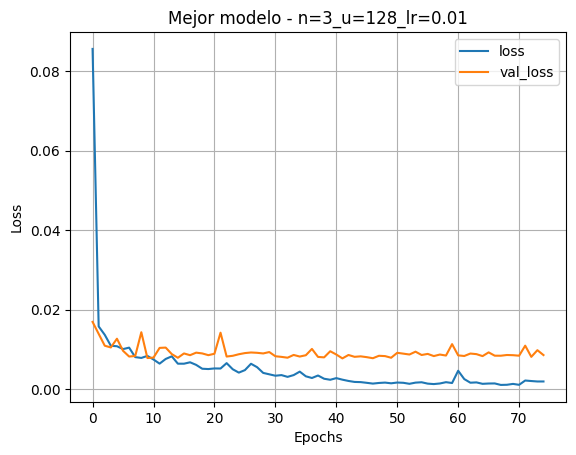

In [ ]:
# Mejor combinación
mejor = df_resultados.iloc[0]
print(f"Mejor combinación: n={mejor['n']}, u={mejor['units']}, lr={mejor['lr']}")
print(f"Val Loss final: {mejor['val_loss']:.6f}")

# Entrenar el mejor modelo y graficar
history_mejor, modelo_final = entrenar_modelo(
    n=int(mejor['n']),
    units=int(mejor['units']),
    learning_rate=mejor['lr'],
    train_set=new_trainset['BandGapLocation'],
    test_set=new_testset['BandGapLocation'],
    n_output=1
)

plt.figure()
plt.plot(history_mejor.history['loss'], label='loss')
plt.plot(history_mejor.history['val_loss'], label='val_loss')
plt.title(f"Mejor modelo - n={int(mejor['n'])}_u={int(mejor['units'])}_lr={mejor['lr']}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import itertools

capas = [1, 2, 3]
neuronas = [16, 64, 256]
learning_rates = [0.001, 0.005]

combinaciones = list(itertools.product(capas, neuronas, learning_rates))

resultados_location = []
resultados_width = []

for n, u, lr in combinaciones:
    print(f"Entrenando: n={n}, u={u}, lr={lr}...")

    # BandGapLocation
    history_loc, _ = entrenar_modelo(
        n=n, units=u, learning_rate=lr,
        train_set=new_trainset['BandGapLocation'],
        test_set=new_testset['BandGapLocation'],
        n_output=1
    )
    resultados_location.append({
        'n': n, 'units': u, 'lr': lr,
        'val_loss': history_loc.history['val_loss'][-1]
    })

    # BandGapWidth
    history_wid, _ = entrenar_modelo(
        n=n, units=u, learning_rate=lr,
        train_set=new_trainset['BandGapWidth'],
        test_set=new_testset['BandGapWidth'],
        n_output=1
    )
    resultados_width.append({
        'n': n, 'units': u, 'lr': lr,
        'val_loss': history_wid.history['val_loss'][-1]
    })

df_location = pd.DataFrame(resultados_location).sort_values('val_loss').reset_index(drop=True)
df_width    = pd.DataFrame(resultados_width).sort_values('val_loss').reset_index(drop=True)

print("\n=== Top 5 BandGapLocation ===")
print(df_location.head())
print("\n=== Top 5 BandGapWidth ===")
print(df_width.head())

Entrenando: n=1, u=16, lr=0.001...
Entrenando: n=1, u=16, lr=0.005...
Entrenando: n=1, u=64, lr=0.001...
Entrenando: n=1, u=64, lr=0.005...
Entrenando: n=1, u=256, lr=0.001...
Entrenando: n=1, u=256, lr=0.005...
Entrenando: n=2, u=16, lr=0.001...
Entrenando: n=2, u=16, lr=0.005...
Entrenando: n=2, u=64, lr=0.001...
Entrenando: n=2, u=64, lr=0.005...
Entrenando: n=2, u=256, lr=0.001...
Entrenando: n=2, u=256, lr=0.005...
Entrenando: n=3, u=16, lr=0.001...
Entrenando: n=3, u=16, lr=0.005...
Entrenando: n=3, u=64, lr=0.001...
Entrenando: n=3, u=64, lr=0.005...
Entrenando: n=3, u=256, lr=0.001...
Entrenando: n=3, u=256, lr=0.005...

=== Top 5 BandGapLocation ===
   n  units     lr  val_loss
0  3    256  0.005  0.007544
1  2    256  0.005  0.008441
2  2     16  0.005  0.008542
3  2     64  0.005  0.008572
4  3     16  0.001  0.009150

=== Top 5 BandGapWidth ===
   n  units     lr  val_loss
0  3    256  0.005  0.005358
1  3    256  0.001  0.005905
2  2    256  0.005  0.006622
3  3     64  0.


  GRAFICAS: BandGapLocation


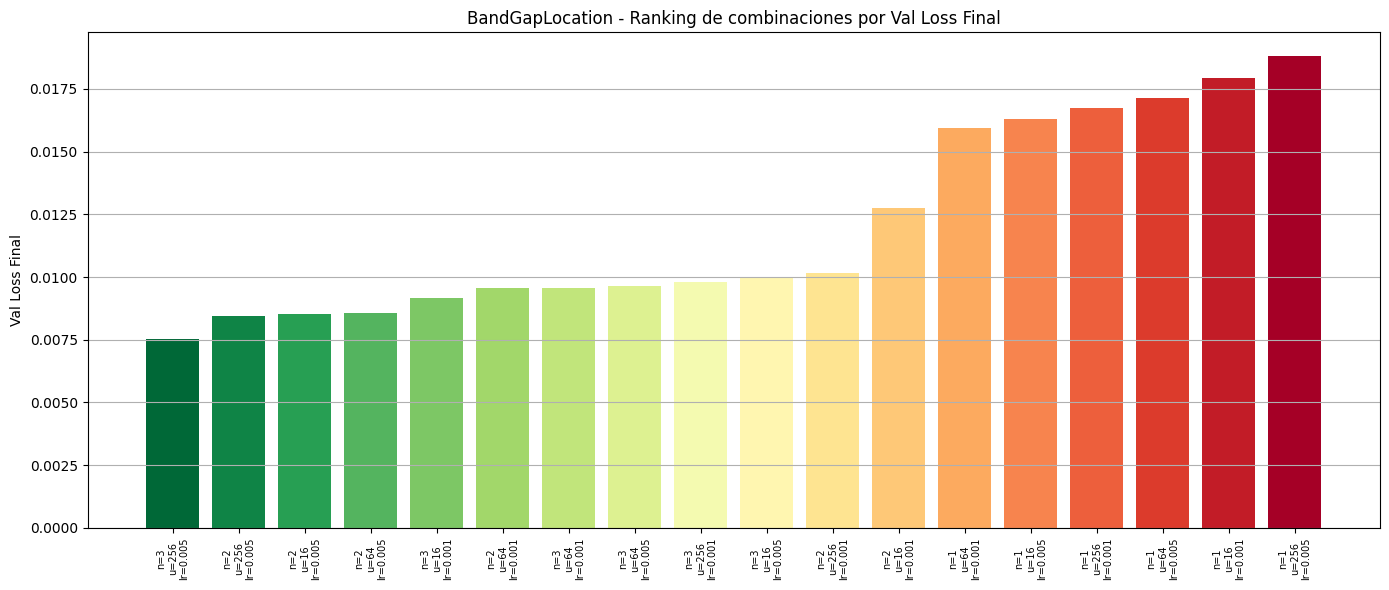

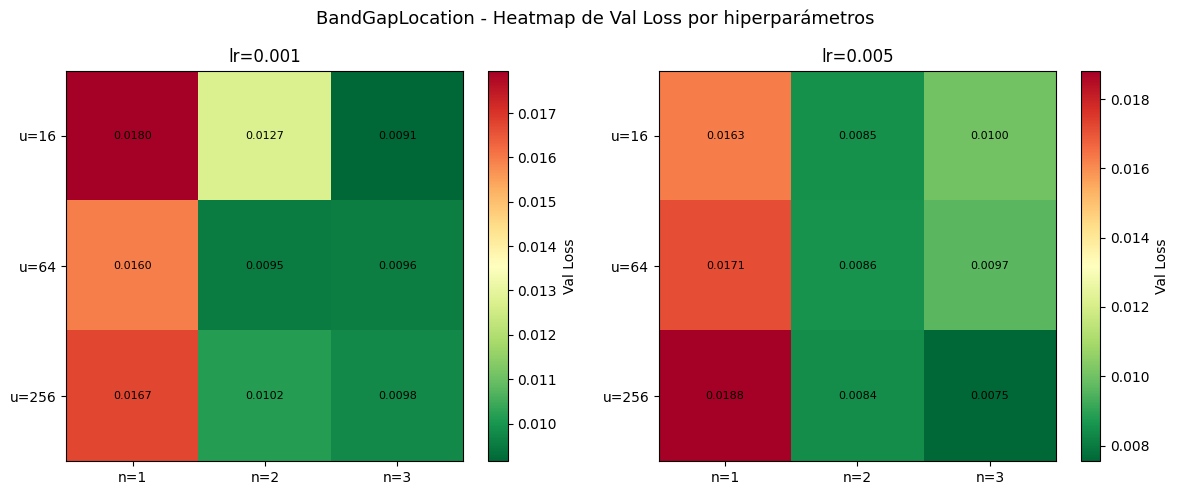

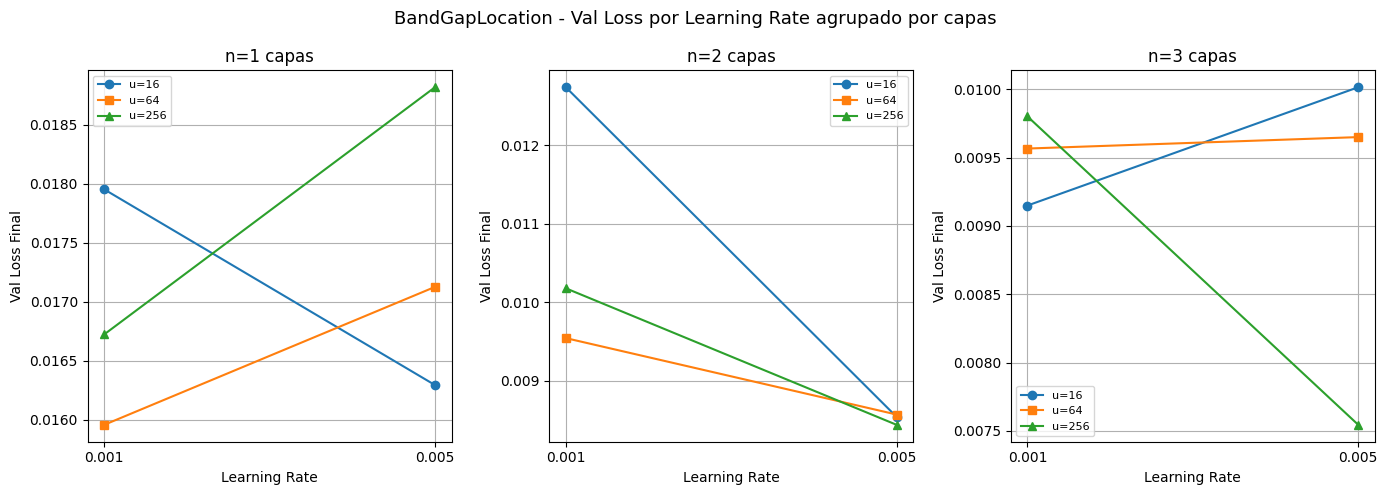

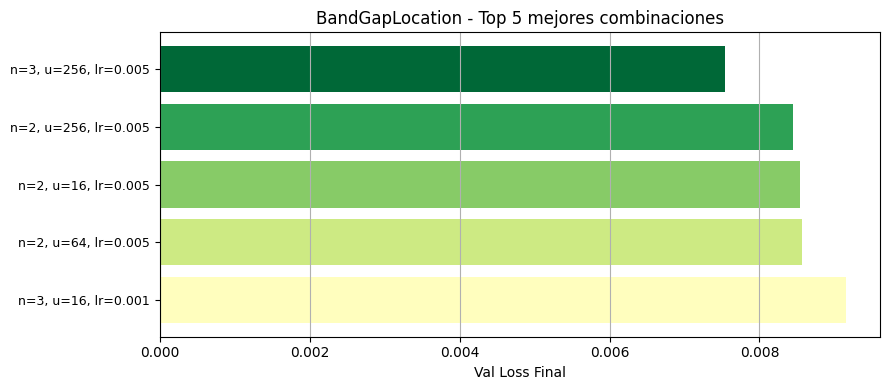


  GRAFICAS: BandGapWidth


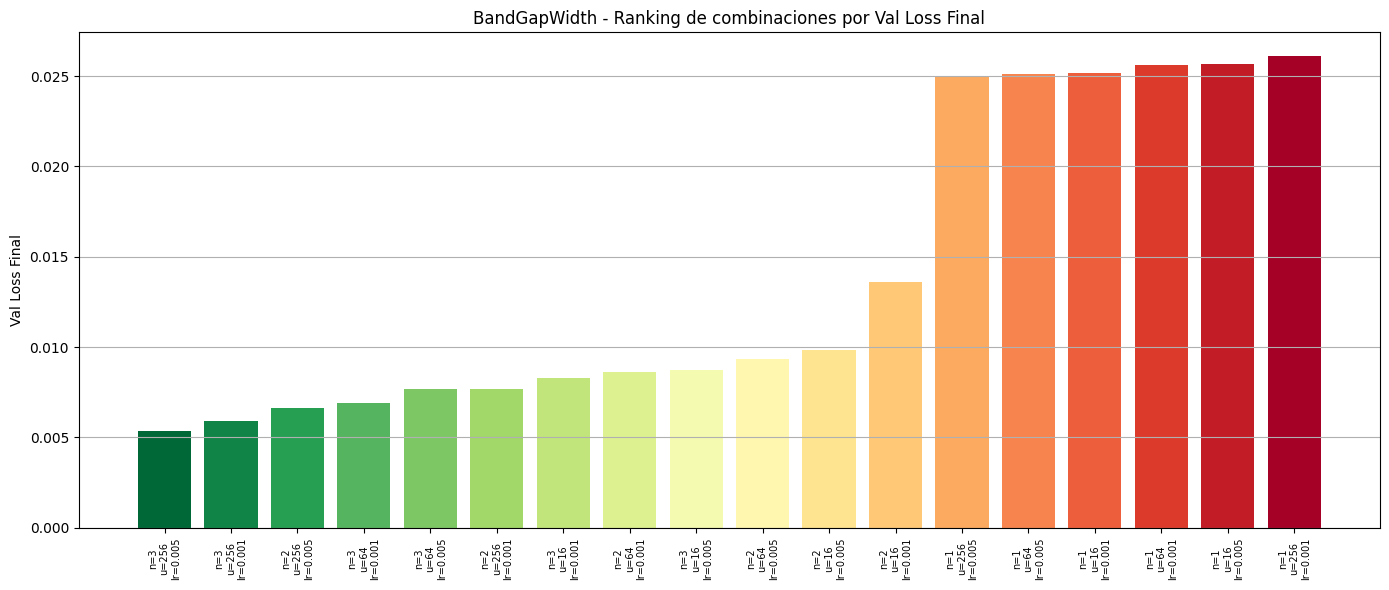

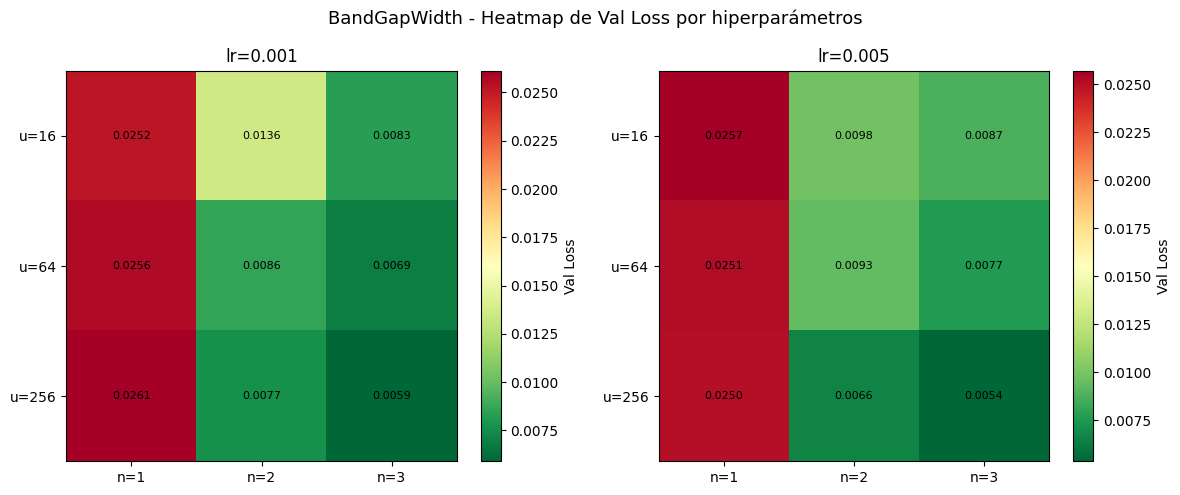

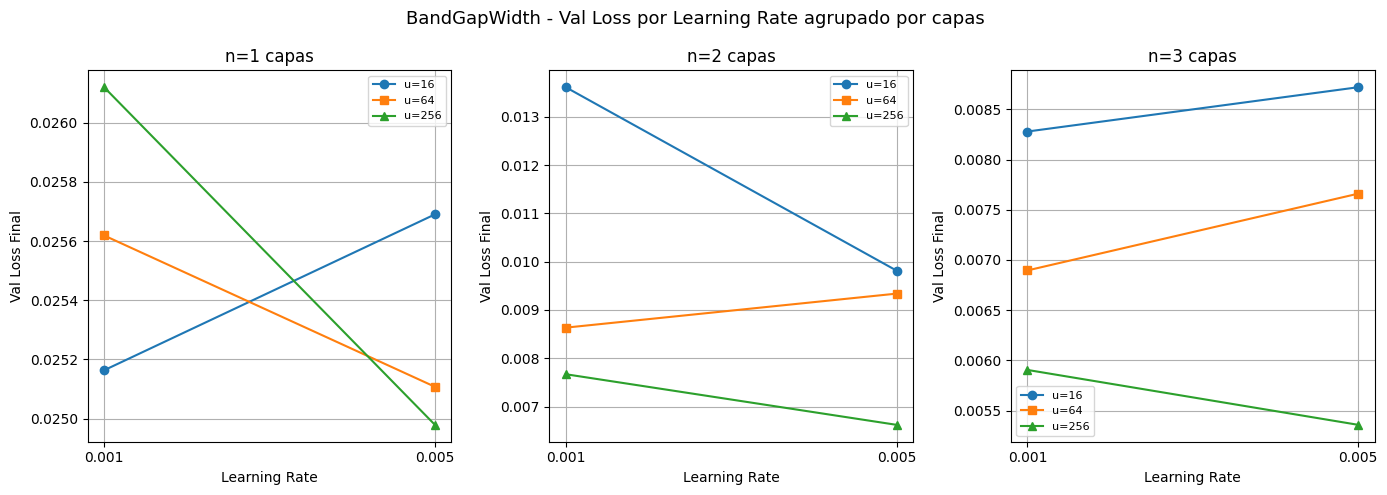

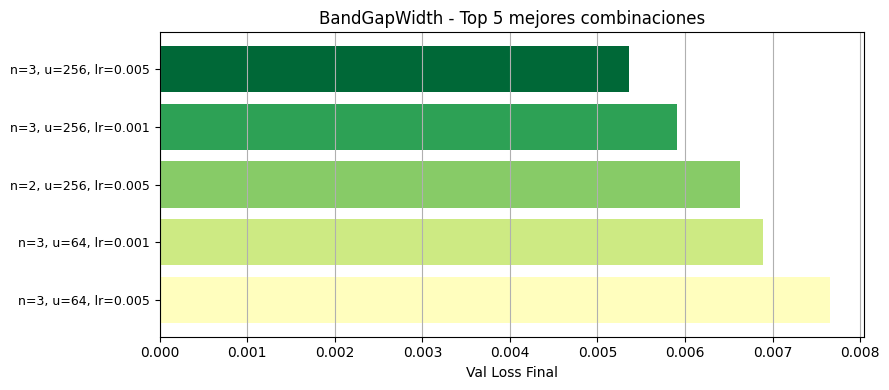

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

for nombre, df_plot in [('BandGapLocation', df_location), ('BandGapWidth', df_width)]:

    print(f"\n{'='*50}")
    print(f"  GRAFICAS: {nombre}")
    print(f"{'='*50}")

    # ============================================================
    # GRÁFICO 1: Val Loss final por combinación (ranking)
    # ============================================================
    fig, ax = plt.subplots(figsize=(14, 6))

    colores = cm.RdYlGn_r(np.linspace(0, 1, len(df_plot)))
    ax.bar(range(len(df_plot)), df_plot['val_loss'], color=colores)

    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(
        [f"n={int(r['n'])}\nu={int(r['units'])}\nlr={r['lr']}" for _, r in df_plot.iterrows()],
        fontsize=7, rotation=90
    )
    ax.set_ylabel("Val Loss Final")
    ax.set_title(f"{nombre} - Ranking de combinaciones por Val Loss Final")
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # ============================================================
    # GRÁFICO 2: Heatmap - Val Loss por n y units (por learning rate)
    # ============================================================
    fig, axes = plt.subplots(1, len(learning_rates), figsize=(12, 5))

    for idx, lr in enumerate(learning_rates):
        subset = df_plot[df_plot['lr'] == lr]
        pivot = subset.pivot(index='units', columns='n', values='val_loss')

        im = axes[idx].imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
        axes[idx].set_xticks(range(len(pivot.columns)))
        axes[idx].set_xticklabels([f"n={c}" for c in pivot.columns])
        axes[idx].set_yticks(range(len(pivot.index)))
        axes[idx].set_yticklabels([f"u={i}" for i in pivot.index])
        axes[idx].set_title(f"lr={lr}")

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    axes[idx].text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)

        plt.colorbar(im, ax=axes[idx], label='Val Loss')

    fig.suptitle(f"{nombre} - Heatmap de Val Loss por hiperparámetros", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # GRÁFICO 3: Val Loss por learning rate (agrupado por n)
    # ============================================================
    fig, axes = plt.subplots(1, len(capas), figsize=(14, 5))
    markers = ['o', 's', '^']

    for idx, n_val in enumerate(capas):
        subset = df_plot[df_plot['n'] == n_val]
        for j, u_val in enumerate(neuronas):
            data = subset[subset['units'] == u_val].sort_values('lr')
            axes[idx].plot(data['lr'].astype(str), data['val_loss'],
                           marker=markers[j], label=f"u={u_val}")
        axes[idx].set_title(f"n={n_val} capas")
        axes[idx].set_xlabel("Learning Rate")
        axes[idx].set_ylabel("Val Loss Final")
        axes[idx].legend(fontsize=8)
        axes[idx].grid()

    fig.suptitle(f"{nombre} - Val Loss por Learning Rate agrupado por capas", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # GRÁFICO 4: Top 5 mejores combinaciones
    # ============================================================
    top5 = df_plot.head(5)

    fig, ax = plt.subplots(figsize=(9, 4))
    colores_top = cm.RdYlGn_r(np.linspace(0, 0.5, len(top5)))
    ax.barh(range(len(top5)), top5['val_loss'], color=colores_top)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(
        [f"n={int(r['n'])}, u={int(r['units'])}, lr={r['lr']}" for _, r in top5.iterrows()],
        fontsize=9
    )
    ax.invert_yaxis()
    ax.set_xlabel("Val Loss Final")
    ax.set_title(f"{nombre} - Top 5 mejores combinaciones")
    ax.grid(axis='x')
    plt.tight_layout()
    plt.show()

KeyError: 'history'

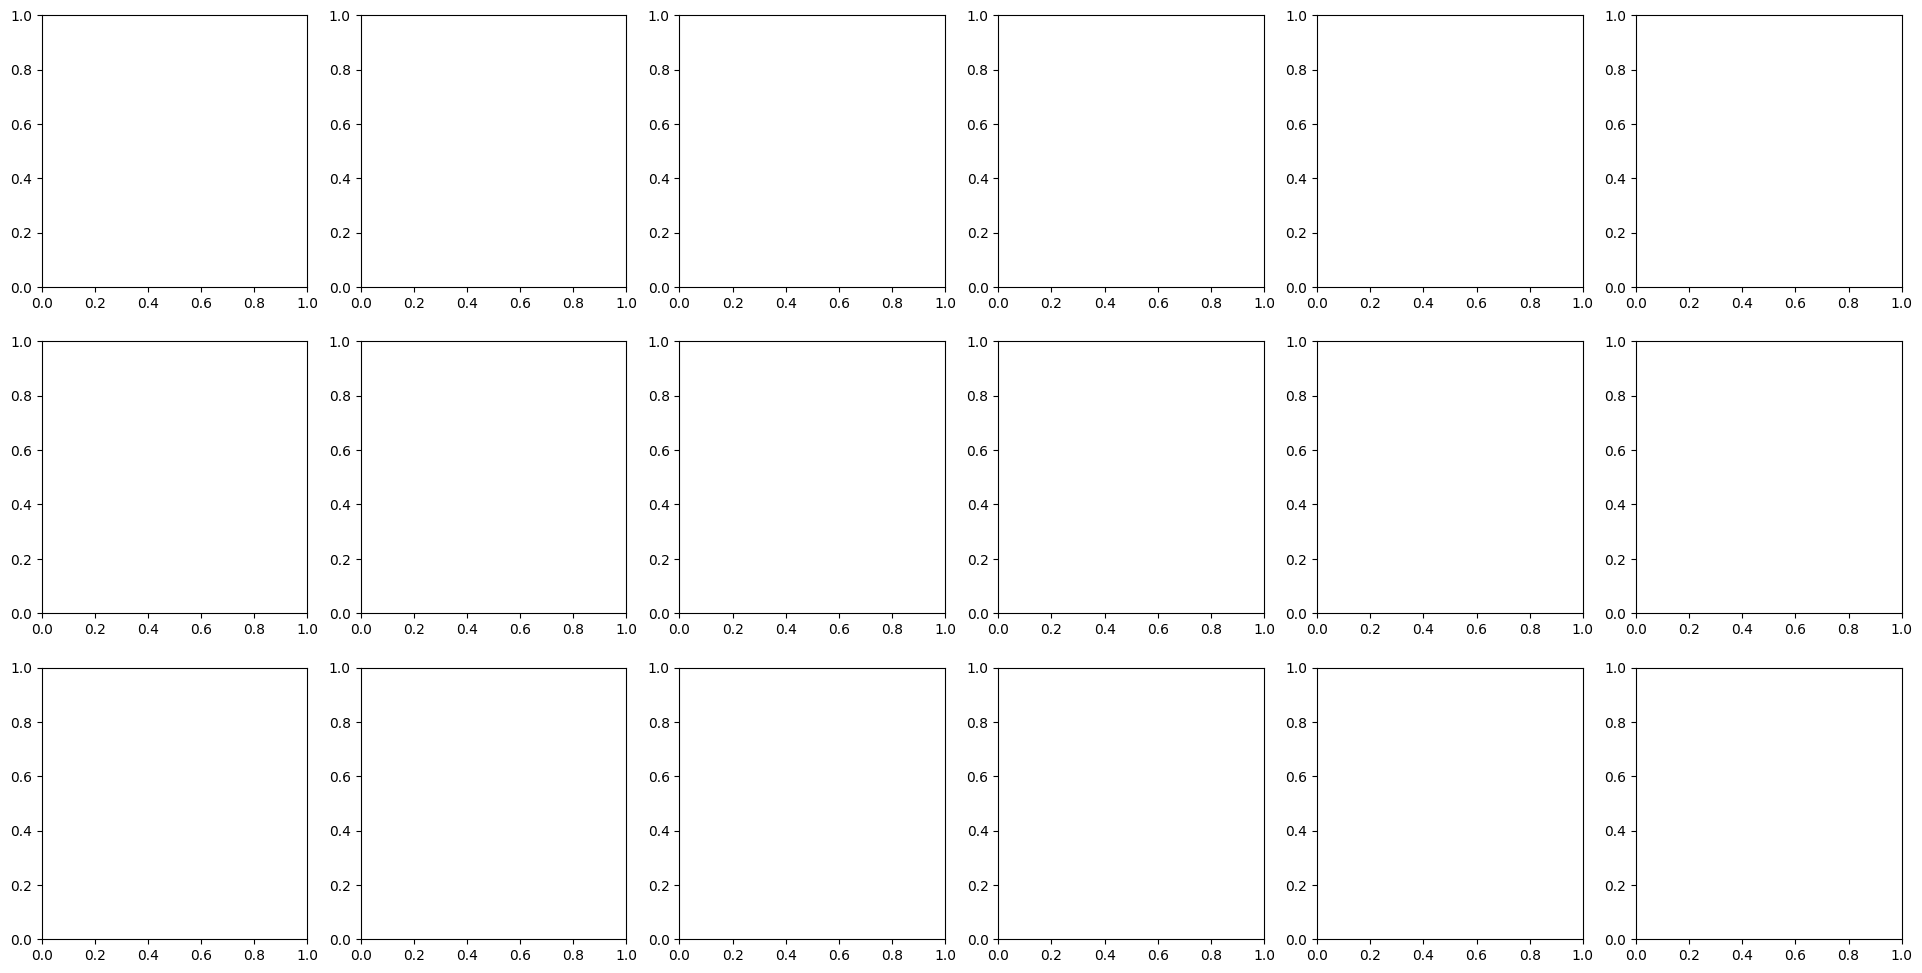

In [ ]:
for nombre, resultados in [('BandGapLocation', resultados_location), ('BandGapWidth', resultados_width)]:

    fig, axes = plt.subplots(3, 6, figsize=(24, 12))
    axes = axes.flatten()

    for idx, res in enumerate(resultados):
        axes[idx].plot(res['history']['loss'], label='loss')
        axes[idx].plot(res['history']['val_loss'], label='val_loss')
        axes[idx].set_title(f"n={res['n']}, u={res['units']}, lr={res['lr']}", fontsize=8)
        axes[idx].set_xlabel("Epochs", fontsize=7)
        axes[idx].set_ylabel("Loss", fontsize=7)
        axes[idx].legend(fontsize=6)
        axes[idx].grid()

    fig.suptitle(f"Curvas de entrenamiento - {nombre}", fontsize=14)
    plt.tight_layout()
    plt.show()